In [1]:
#setup
#%pip install requests
#%pip install openmeteo-requests
#%pip install requests-cache retry-requests numpy pandas
#%pip install matplotlib
import requests
import json
import openmeteo_requests
import requests_cache
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from retry_requests import retry

In [8]:
# get matches
matches = {}

# uncomment to do the analysis for all the leagues
#response = json.loads(requests.get("https://api.openligadb.de/getavailableleagues").text)
#for league in response:
#    matches[league["leagueName"]] = json.loads(requests.get(f"https://api.openligadb.de/getmatchdata/{league['leagueShortcut']}/{league['leagueSeason']}").text)

matches["1. Fussball-Bundesliga 2022/2023"] = json.loads(requests.get("https://api.openligadb.de/getmatchdata/bl1/2022").text)

In [3]:
# get weather on the day of each match
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)


for match_collection in matches.values():
    j=0
    for match in match_collection:
        if not match["matchDateTime"] or not match["location"] or not match["location"]["locationCity"]: 
            # if the location of the match isn't recorded, use the short name of the home team (which is usually their city)
            if match["team1"]["shortName"]:
                match["location"] = {"locationCity":match["team1"]["shortName"]}
            else:
                j+=1
                continue # skip entries with missing data
        match_date = match["matchDateTime"][:10] # first 10 chars are date, rest is time
        location = match["location"]["locationCity"]
        coords = json.loads(requests.get(f"https://geocoding-api.open-meteo.com/v1/search?name={location}&language=de&countryCode=DE&count=3").text)
        if "results" not in coords: 
            print(f"Found no result when searching '{location}'")
            j+=1
            continue
        elif not len(coords["results"]) == 1:
            print(f"City lookup was ambiguous when searching '{location}'. Using first result.")
        params={
            "latitude": coords["results"][0]["latitude"],
            "longitude": coords["results"][0]["longitude"],
            "start_date": match_date,
            "end_date": match_date,
            "daily": ["precipitation_sum", "rain_sum"],
        }
        # dis shit ugly as hell
        weather = openmeteo.weather_api("https://archive-api.open-meteo.com/v1/archive", params=params)[0].Daily()
        match["precipitation"]=weather.Variables(0).ValuesAsNumpy()[0]
        match["rain"]=weather.Variables(1).ValuesAsNumpy()[0] # units are mm
        match_collection[j] = match
        j+=1



City lookup was ambiguous when searching 'Frankfurt'. Using first result.
City lookup was ambiguous when searching 'Augsburg'. Using first result.
City lookup was ambiguous when searching 'Bochum'. Using first result.
City lookup was ambiguous when searching 'Gladbach'. Using first result.
City lookup was ambiguous when searching 'Wolfsburg'. Using first result.
City lookup was ambiguous when searching 'Dortmund'. Using first result.
City lookup was ambiguous when searching 'Leverkusen'. Using first result.
City lookup was ambiguous when searching 'Schalke'. Using first result.
City lookup was ambiguous when searching 'Mainz'. Using first result.
City lookup was ambiguous when searching 'Bayern'. Using first result.
City lookup was ambiguous when searching 'Gladbach'. Using first result.
City lookup was ambiguous when searching 'Augsburg'. Using first result.
City lookup was ambiguous when searching 'Leverkusen'. Using first result.
City lookup was ambiguous when searching 'Dortmund'. 

Text(0.5, 0, '# Matches')

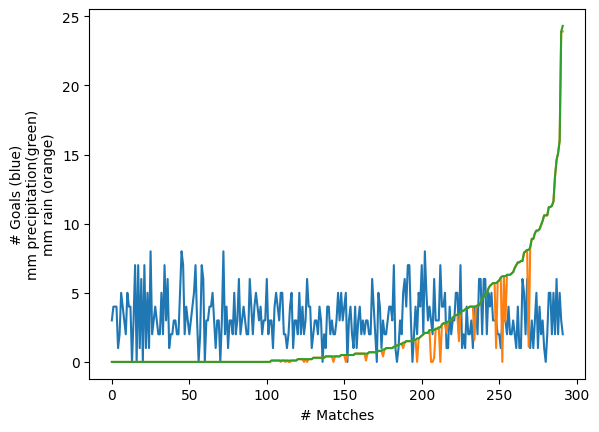

In [ ]:
# graphical representation
# extract relevant data and sort
data = np.array(sorted([(len(match["goals"]), match["rain"], match["precipitation"]) for match in list(matches.values())[0] if "rain" in match], key = lambda x:x[2])).transpose()
plot = plt.plot(range(len(data[0])), data[0]) # plot number of goals
plot.append(plt.plot(range(len(data[0])), data[1])) # plot rain
plot.append(plt.plot(range(len(data[0])), data[2])) # plot precipitation
plt.ylabel("# Goals (blue)\nmm precipitation(green)\nmm rain (orange)")
plt.xlabel("# Matches")

